In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import sys

sys.path.append('../')
from plotting_helper_funcs import *

%matplotlib inline
plt.style.use('~/.matplotlib/stylelib/custom.mplstyle')
mpl.rcParams['figure.autolayout'] = True
cols = sns.color_palette(palette='colorblind', n_colors=3)

We want to load the data from the Schimtt et al. exeriments. The authors provide an excell file where each sheet is the data show in each figure.
This file is `../../../Schmitt_et_al_2022_data/Numerical_Source_data.xlsx`. We parse the data from figure 2 into a new file `../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx` to ease loading via pandas.

Note that the following Fig 2 panels have the noted correspondence:
- 2b - WT ExRai-AMPKAR at the Lysosome 
- 2c - WT ExRai-AMPKAR at the Mitochondria
- 2d - WT ExRai-AMPKAR at the Cytoplasm

Next, we load the sheets as pandas data frames, keeping only the rows and columns with the times, WT mean, and WT STDEV.

In [21]:
# fig 2b - lysosome data
lyso_df = pd.read_excel('../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx', 
                          sheet_name='Figure 2b', skiprows=5, usecols='A:C', names=['Time (min)', 'WT MEAN', 'WT SDEV'])
# fig 2c - mitochondria data
mito_df = pd.read_excel('../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx', 
                          sheet_name='Figure 2c', skiprows=5, usecols='A:C', names=['Time (min)', 'WT MEAN', 'WT SDEV'])
# fig 2e - cytoplasm data
cyto_df = pd.read_excel('../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx', 
                          sheet_name='Figure 2e', skiprows=5, usecols='A:C', names=['Time (min)', 'WT MEAN', 'WT SDEV'])


Note that the data given contain $\bar{R}(t)$ which is the mean over $N$ cells over time and $\sigma_{R}(t)$ which is the standard deviation over $N$ cells over time. 

We normalize the data such that we can relate the normalized measurements to the ratio of phosphorylated to unphosphorylated sensor (following the advice of Greenwald et al. 2014).
First we compute the min and max of $\bar{R}(t)$. Then we compute normalized ratio, which is defined
$$
R_{\rm norm}(t) \equiv \frac{\bar{R}(t) - R_{\rm min}}{R_{\rm max} - R_{\rm min}},
$$
which is equivalent to normalizing the data from each cell to min and max of the average of all cells.

Next, we need to normalize the standard deviation. We use the following formula
$$
\sigma^2_{R_{\rm norm}}(t) = \frac{\sigma^2_{R}(t)}{(R_{\rm max} - R_{\rm min})^2}
$$
which comes from computing the variance of the normalized data.

In [33]:
# function to normalize data mean and standard deviation
def compute_normalized_data(df):
    """ Normalize data mean and standard deviation """
    norm_mean = (df['WT MEAN'] - df['WT MEAN'].min()) / (df['WT MEAN'].max() - df['WT MEAN'].min())
    norm_sd = df['WT SDEV'] / (df['WT MEAN'].max() - df['WT MEAN'].min())
    return norm_mean, norm_sd

norm_cyto, norm_cyto_sd = compute_normalized_data(cyto_df)
norm_lyso, norm_lyso_sd = compute_normalized_data(lyso_df)
norm_mito, norm_mito_sd = compute_normalized_data(mito_df)

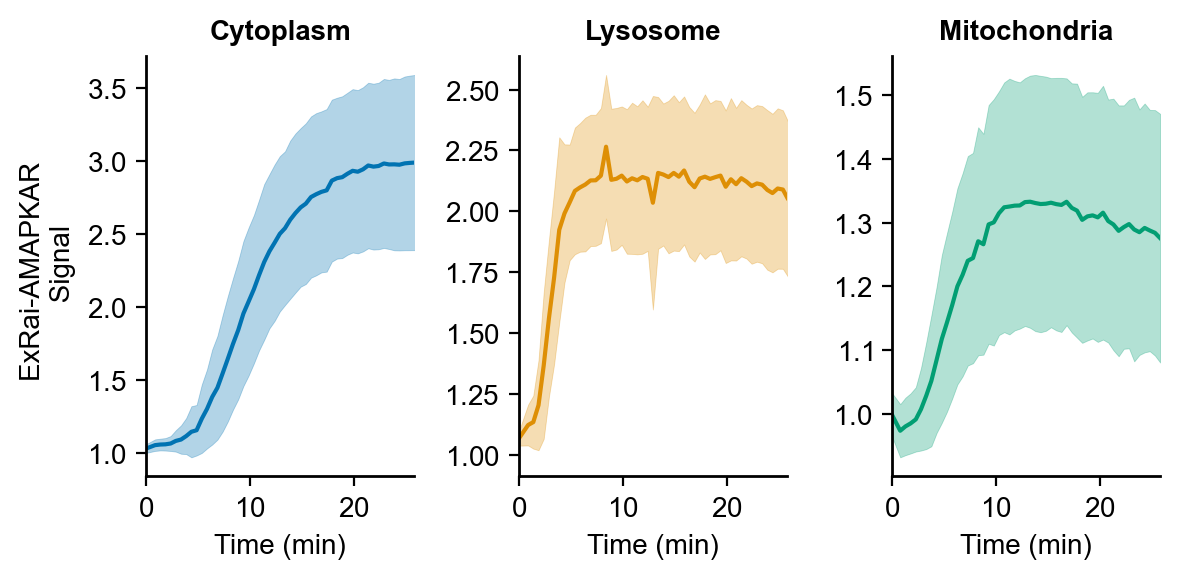

In [66]:
# make a plot of raw data
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(6, 3))
ax[0].plot(cyto_df['Time (min)'], cyto_df["WT MEAN"], label='cytoplasm', color=cols[0])
ax[0].fill_between(cyto_df['Time (min)'], cyto_df["WT MEAN"] + cyto_df["WT SDEV"], cyto_df["WT MEAN"] - cyto_df["WT SDEV"], alpha=0.3, color=cols[0])
ax[1].plot(lyso_df['Time (min)'], lyso_df["WT MEAN"], label='lysosome', color=cols[1])
ax[1].fill_between(lyso_df['Time (min)'], lyso_df["WT MEAN"] + lyso_df["WT SDEV"], lyso_df["WT MEAN"] - lyso_df["WT SDEV"], alpha=0.3, color=cols[1])
ax[2].plot(mito_df['Time (min)'], mito_df["WT MEAN"], label='mitochondria', color=cols[2])
ax[2].fill_between(mito_df['Time (min)'], mito_df["WT MEAN"] + mito_df["WT SDEV"], mito_df["WT MEAN"] - mito_df["WT SDEV"], alpha=0.3, color=cols[2])
# ax.legend(loc='upper left')
ax[0].set_ylabel('ExRai-AMAPKAR \n Signal', fontsize=10)

titles = ['Cytoplasm', 'Lysosome', 'Mitochondria']
for i in range(3):
    ax[i].set_xlabel('Time (min)', fontsize=10)
    ax[i].set_xlim([0.0, 25.8])
    ax[i].set_title(titles[i], fontsize=10)
   
fig.savefig('../../../figures/schmitt_f2.pdf')

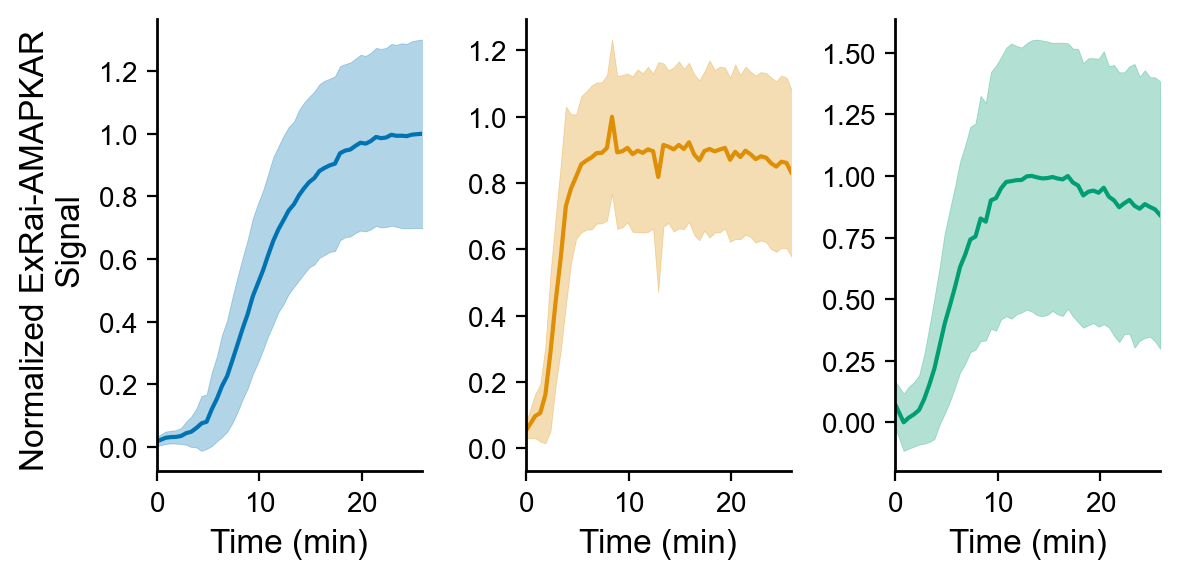

In [67]:
# make a plot of normalized data
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(6, 3))
ax[0].plot(cyto_df['Time (min)'], norm_cyto, label='cytoplasm', color=cols[0])
ax[0].fill_between(cyto_df['Time (min)'], norm_cyto + norm_cyto_sd, norm_cyto - norm_cyto_sd, alpha=0.3, color=cols[0])
ax[1].plot(lyso_df['Time (min)'], norm_lyso, label='lysosome', color=cols[1])
ax[1].fill_between(lyso_df['Time (min)'], norm_lyso + norm_lyso_sd, norm_lyso - norm_lyso_sd, alpha=0.3, color=cols[1])
ax[2].plot(mito_df['Time (min)'], norm_mito, label='mitochondria', color=cols[2])
ax[2].fill_between(mito_df['Time (min)'], norm_mito + norm_mito_sd, norm_mito - norm_mito_sd, alpha=0.3, color=cols[2])
# ax.legend(loc='upper left')
ax[0].set_ylabel('Normalized ExRai-AMAPKAR \n Signal')
for i in range(3):
    ax[i].set_xlabel('Time (min)')
    ax[i].set_xlim([0.0, 25.8])
    # ax[i].set_ylim([0.0, 1.5])
fig.savefig('../../../figures/schmitt_f2_renorm.pdf')

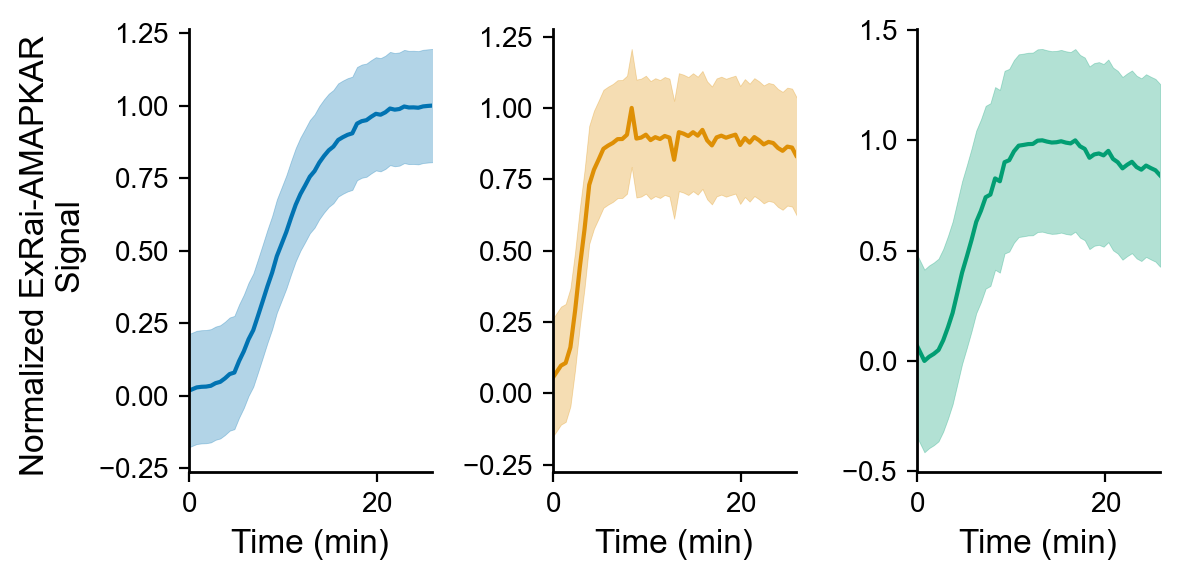

In [71]:
# constant sd
# make a plot of normalized data
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(6, 3))
ax[0].plot(cyto_df['Time (min)'], norm_cyto, label='cytoplasm', color=cols[0])
ax[0].fill_between(cyto_df['Time (min)'], norm_cyto + norm_cyto_sd.mean(), norm_cyto - norm_cyto_sd.mean(), alpha=0.3, color=cols[0])
ax[1].plot(lyso_df['Time (min)'], norm_lyso, label='lysosome', color=cols[1])
ax[1].fill_between(lyso_df['Time (min)'], norm_lyso + norm_lyso_sd.mean(), norm_lyso - norm_lyso_sd.mean(), alpha=0.3, color=cols[1])
ax[2].plot(mito_df['Time (min)'], norm_mito, label='mitochondria', color=cols[2])
ax[2].fill_between(mito_df['Time (min)'], norm_mito + norm_mito_sd.mean(), norm_mito - norm_mito_sd.mean(), alpha=0.3, color=cols[2])
# ax.legend(loc='upper left')
ax[0].set_ylabel('Normalized ExRai-AMAPKAR \n Signal')
for i in range(3):
    ax[i].set_xlabel('Time (min)')
    ax[i].set_xlim([0.0, 25.8])
    # ax[i].set_ylim([0.0, 1.5])
fig.savefig('../../../figures/schmitt_f2_renorm_constan_SD.pdf')

In [73]:
# save all of the renormalized data
np.savez('../../../Schmitt_et_al_2022_data/fig_2b_lyso.npz', times=lyso_df['Time (min)'].to_numpy(), 
         mean=norm_lyso.to_numpy(), std=norm_lyso_sd.to_numpy(), 
         std_constant=norm_lyso_sd.mean())
np.savez('../../../Schmitt_et_al_2022_data/fig_2c_mito.npz', times=mito_df['Time (min)'].to_numpy(), 
         mean=norm_mito.to_numpy(), std=norm_cyto_sd.to_numpy(), 
         std_constant=norm_mito_sd.mean())
np.savez('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz', times=cyto_df['Time (min)'].to_numpy(), 
         mean=norm_cyto.to_numpy(), std=norm_cyto_sd.to_numpy(), 
         std_constant=norm_cyto_sd.mean())